In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scikit_posthocs as sp
from utils import *

In [2]:
results = pd.concat([pd.read_csv(f).assign(file=f) for f in glob.glob("results/*.csv")]).assign(
    configuration=lambda df: df["file"].apply(lambda row: row[-9:-8]),
    scenario=lambda df: df["file"].apply(lambda row: row[-7:-6]),
    noise_level=lambda df: df["file"].apply(lambda row: row[-5:-4])
).drop("column", axis=1)

In [3]:
results

,Best model-mean_distance,Best model-root_mean_square_distance,Best model-inner-q0.05-mean_distance,Best model-inner-q0.05-root_mean_square_distance,Best model-outer-q0.05-mean_distance,Best model-outer-q0.05-root_mean_square_distance,Best model-inner-q0.1-mean_distance,Best model-inner-q0.1-root_mean_square_distance,Best model-outer-q0.1-mean_distance,Best model-outer-q0.1-root_mean_square_distance,...,Best stacked ensemble-inner-q0.1-root_mean_square_distance,Best stacked ensemble-outer-q0.1-mean_distance,Best stacked ensemble-outer-q0.1-root_mean_square_distance,Best stacked ensemble-inner-q0.25-mean_distance,Best stacked ensemble-inner-q0.25-root_mean_square_distance,Best stacked ensemble-outer-q0.25-mean_distance,Best stacked ensemble-outer-q0.25-root_mean_square_distance,configuration,scenario,noise_level
0,0.027703,0.033097,0.027984,0.033047,0.025173,0.033542,0.027715,0.032767,0.027655,0.034382,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,3,1
1,0.026018,0.026146,0.026018,0.026146,NaN,NaN,0.026018,0.026146,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,3,1
2,0.057761,0.073836,0.056347,0.071970,0.070484,0.088887,0.054580,0.069566,0.070484,0.088887,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,3,1
3,0.113741,0.135961,0.114203,0.137229,0.109584,0.123964,0.120687,0.143155,0.085960,0.102242,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,3,1
4,0.065159,0.084959,0.060921,0.077966,0.103295,0.132186,0.056451,0.070923,0.099988,0.126374,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,0.177025,0.199034,0.168574,0.181622,0.253078,0.315061,0.170475,0.179302,0.203224,0.263582,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,L,3,9
5,0.070778,0.089669,0.070778,0.089669,NaN,NaN,0.070778,0.089669,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,L,3,9
6,0.308280,0.470090,0.220543,0.329181,1.097913,1.111128,0.154307,0.218777,0.924170,0.955757,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,L,3,9
7,0.025057,0.033904,0.025057,0.033904,NaN,NaN,0.025057,0.033904,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,L,3,9


In [4]:
results.describe().style

,Best model-mean_distance,Best model-root_mean_square_distance,Best model-inner-q0.05-mean_distance,Best model-inner-q0.05-root_mean_square_distance,Best model-outer-q0.05-mean_distance,Best model-outer-q0.05-root_mean_square_distance,Best model-inner-q0.1-mean_distance,Best model-inner-q0.1-root_mean_square_distance,Best model-outer-q0.1-mean_distance,Best model-outer-q0.1-root_mean_square_distance,Best model-inner-q0.25-mean_distance,Best model-inner-q0.25-root_mean_square_distance,Best model-outer-q0.25-mean_distance,Best model-outer-q0.25-root_mean_square_distance,Best basemodel-mean_distance,Best basemodel-root_mean_square_distance,Best basemodel-inner-q0.05-mean_distance,Best basemodel-inner-q0.05-root_mean_square_distance,Best basemodel-outer-q0.05-mean_distance,Best basemodel-outer-q0.05-root_mean_square_distance,Best basemodel-inner-q0.1-mean_distance,Best basemodel-inner-q0.1-root_mean_square_distance,Best basemodel-outer-q0.1-mean_distance,Best basemodel-outer-q0.1-root_mean_square_distance,Best basemodel-inner-q0.25-mean_distance,Best basemodel-inner-q0.25-root_mean_square_distance,Best basemodel-outer-q0.25-mean_distance,Best basemodel-outer-q0.25-root_mean_square_distance,All models-mean_distance,All models-root_mean_square_distance,All models-inner-q0.05-mean_distance,All models-inner-q0.05-root_mean_square_distance,All models-outer-q0.05-mean_distance,All models-outer-q0.05-root_mean_square_distance,All models-inner-q0.1-mean_distance,All models-inner-q0.1-root_mean_square_distance,All models-outer-q0.1-mean_distance,All models-outer-q0.1-root_mean_square_distance,All models-inner-q0.25-mean_distance,All models-inner-q0.25-root_mean_square_distance,All models-outer-q0.25-mean_distance,All models-outer-q0.25-root_mean_square_distance,Rashomon-mean_distance,Rashomon-root_mean_square_distance,Rashomon-inner-q0.05-mean_distance,Rashomon-inner-q0.05-root_mean_square_distance,Rashomon-outer-q0.05-mean_distance,Rashomon-outer-q0.05-root_mean_square_distance,Rashomon-inner-q0.1-mean_distance,Rashomon-inner-q0.1-root_mean_square_distance,Rashomon-outer-q0.1-mean_distance,Rashomon-outer-q0.1-root_mean_square_distance,Rashomon-inner-q0.25-mean_distance,Rashomon-inner-q0.25-root_mean_square_distance,Rashomon-outer-q0.25-mean_distance,Rashomon-outer-q0.25-root_mean_square_distance,Best of Family-mean_distance,Best of Family-root_mean_square_distance,Best of Family-inner-q0.05-mean_distance,Best of Family-inner-q0.05-root_mean_square_distance,Best of Family-outer-q0.05-mean_distance,Best of Family-outer-q0.05-root_mean_square_distance,Best of Family-inner-q0.1-mean_distance,Best of Family-inner-q0.1-root_mean_square_distance,Best of Family-outer-q0.1-mean_distance,Best of Family-outer-q0.1-root_mean_square_distance,Best of Family-inner-q0.25-mean_distance,Best of Family-inner-q0.25-root_mean_square_distance,Best of Family-outer-q0.25-mean_distance,Best of Family-outer-q0.25-root_mean_square_distance,Best of Family models ∩ Rashomon models-mean_distance,Best of Family models ∩ Rashomon models-root_mean_square_distance,Best of Family models ∩ Rashomon models-inner-q0.05-mean_distance,Best of Family models ∩ Rashomon models-inner-q0.05-root_mean_square_distance,Best of Family models ∩ Rashomon models-outer-q0.05-mean_distance,Best of Family models ∩ Rashomon models-outer-q0.05-root_mean_square_distance,Best of Family models ∩ Rashomon models-inner-q0.1-mean_distance,Best of Family models ∩ Rashomon models-inner-q0.1-root_mean_square_distance,Best of Family models ∩ Rashomon models-outer-q0.1-mean_distance,Best of Family models ∩ Rashomon models-outer-q0.1-root_mean_square_distance,Best of Family models ∩ Rashomon models-inner-q0.25-mean_distance,Best of Family models ∩ Rashomon models-inner-q0.25-root_mean_square_distance,Best of Family models ∩ Rashomon models-outer-q0.25-mean_distance,Best of Family models ∩ Rashomon models-outer-q0.25-root_mean_square_distance,Best stacked ensemble-mean_distance,Best stacked ensemble-root_me

In [5]:
for group_by in [["configuration"], ["scenario"], ["noise_level"], ["scenario", "noise_level"], ["configuration", "scenario", "noise_level"]]:
    for metric in ["mean_distance", "root_mean_square_distance"]:
        res = results[[c for c in results.columns if metric in c and "inner" not in c and "outer" not in c] + group_by]
        display(res.groupby(group_by).mean().style.background_gradient(cmap='RdYlGn_r', axis=1))
        res = results[[c for c in results.columns if metric in c and "0.25" in c and "outer" not in c] + group_by]
        display(res.groupby(group_by).mean().style.background_gradient(cmap='RdYlGn_r', axis=1))
        res = results[[c for c in results.columns if metric in c and "0.1" in c and "outer" not in c] + group_by]
        display(res.groupby(group_by).mean().style.background_gradient(cmap='RdYlGn_r', axis=1))
        # res = results[[c for c in results.columns if metric in c and "0.05" in c and "outer" not in c] + group_by]
        # display(res.groupby(group_by).mean().style.background_gradient(cmap='RdYlGn_r', axis=1))
        # res = results[[c for c in results.columns if metric in c and "0.25" in c and "outer" in c] + group_by]
        # display(res.groupby(group_by).mean().style.background_gradient(cmap='RdYlGn_r', axis=1))
        res = results[[c for c in results.columns if metric in c and "0.1" in c and "outer" in c] + group_by]
        display(res.groupby(group_by).mean().style.background_gradient(cmap='RdYlGn_r', axis=1))
        res = results[[c for c in results.columns if metric in c and "0.05" in c and "outer" in c] + group_by]
        display(res.groupby(group_by).mean().style.background_gradient(cmap='RdYlGn_r', axis=1))

,Best model-mean_distance,Best basemodel-mean_distance,All models-mean_distance,Rashomon-mean_distance,Best of Family-mean_distance,Best of Family models ∩ Rashomon models-mean_distance,Best stacked ensemble-mean_distance
configuration,,,,,,,
A,0.177311,0.177311,0.191735,0.167719,0.199675,0.158938,nan
B,0.171158,0.175876,0.216794,0.165574,0.195354,0.154669,0.161681
C,0.159975,0.183968,0.218251,0.170337,0.194533,0.159804,0.159975
D,0.154750,0.174624,0.216934,0.164002,0.189824,0.157613,0.154750
E,0.174860,0.174860,0.192325,0.169281,0.201819,0.159913,nan
F,0.244388,0.244388,0.192562,0.171513,0.200240,0.163998,nan
G,0.235718,0.244524,0.247375,0.181710,0.201420,0.167209,0.110881
H,0.164372,0.242400,0.275735,0.180726,0.190249,0.162290,0.164372
I,0.168511,0.168511,0.183161,0.167055,0.197789,0.156694,nan


,Best model-inner-q0.25-mean_distance,Best basemodel-inner-q0.25-mean_distance,All models-inner-q0.25-mean_distance,Rashomon-inner-q0.25-mean_distance,Best of Family-inner-q0.25-mean_distance,Best of Family models ∩ Rashomon models-inner-q0.25-mean_distance,Best stacked ensemble-inner-q0.25-mean_distance
configuration,,,,,,,
A,0.088688,0.088688,0.086558,0.073214,0.080753,0.072799,nan
B,0.087832,0.086377,0.114782,0.079542,0.081850,0.073656,0.087196
C,0.078880,0.086552,0.114774,0.084358,0.082876,0.077884,0.078880
D,0.073674,0.085216,0.114288,0.079087,0.077216,0.074662,0.073674
E,0.079764,0.079764,0.081271,0.070210,0.082971,0.073458,nan
F,0.166765,0.166765,0.085820,0.077708,0.087457,0.087017,nan
G,0.151500,0.154220,0.137049,0.087780,0.091538,0.091862,0.066979
H,0.089444,0.155245,0.166339,0.094135,0.086223,0.086580,0.089444
I,0.077893,0.077893,0.077413,0.070527,0.081921,0.072384,nan


,Best model-inner-q0.1-mean_distance,Best basemodel-inner-q0.1-mean_distance,All models-inner-q0.1-mean_distance,Rashomon-inner-q0.1-mean_distance,Best of Family-inner-q0.1-mean_distance,Best of Family models ∩ Rashomon models-inner-q0.1-mean_distance,Best stacked ensemble-inner-q0.1-mean_distance
configuration,,,,,,,
A,0.122634,0.122634,0.121769,0.102342,0.127963,0.100994,nan
B,0.115945,0.121353,0.149403,0.105295,0.125973,0.099854,0.108588
C,0.106641,0.124600,0.150631,0.111967,0.126267,0.105340,0.106641
D,0.100515,0.119955,0.149454,0.105717,0.120834,0.102309,0.100515
E,0.116532,0.116532,0.118863,0.100110,0.130166,0.101939,nan
F,0.195618,0.195618,0.122137,0.106665,0.131764,0.111473,nan
G,0.184591,0.190289,0.177614,0.117595,0.134088,0.115502,0.084241
H,0.114867,0.188673,0.207288,0.122841,0.125745,0.111627,0.114867
I,0.104586,0.104586,0.112118,0.099508,0.125819,0.098211,nan


,Best model-outer-q0.1-mean_distance,Best basemodel-outer-q0.1-mean_distance,All models-outer-q0.1-mean_distance,Rashomon-outer-q0.1-mean_distance,Best of Family-outer-q0.1-mean_distance,Best of Family models ∩ Rashomon models-outer-q0.1-mean_distance,Best stacked ensemble-outer-q0.1-mean_distance
configuration,,,,,,,
A,0.565491,0.565491,0.673759,0.617180,0.704558,0.563101,nan
B,0.556629,0.563109,0.680024,0.579601,0.682166,0.536670,0.527838
C,0.533267,0.603894,0.682683,0.572360,0.674107,0.540476,0.533267
D,0.532648,0.563862,0.680379,0.565323,0.673944,0.543150,0.532648
E,0.587598,0.587598,0.697703,0.644362,0.705467,0.563961,nan
F,0.585351,0.585351,0.676607,0.615997,0.681135,0.529255,nan
G,0.594711,0.623696,0.724987,0.620482,0.674686,0.526503,0.313240
H,0.510584,0.614696,0.744424,0.576667,0.642173,0.514078,0.510584
I,0.611905,0.611905,0.672766,0.631909,0.702585,0.562663,nan


,Best model-outer-q0.05-mean_distance,Best basemodel-outer-q0.05-mean_distance,All models-outer-q0.05-mean_distance,Rashomon-outer-q0.05-mean_distance,Best of Family-outer-q0.05-mean_distance,Best of Family models ∩ Rashomon models-outer-q0.05-mean_distance,Best stacked ensemble-outer-q0.05-mean_distance
configuration,,,,,,,
A,0.681938,0.681938,0.805163,0.746726,0.824349,0.683783,nan
B,0.667172,0.679022,0.807222,0.705209,0.800769,0.654079,0.639734
C,0.642730,0.714220,0.808860,0.692308,0.791585,0.654423,0.642730
D,0.645643,0.680755,0.807011,0.686705,0.792416,0.658858,0.645643
E,0.698541,0.698541,0.835321,0.779699,0.824846,0.683770,nan
F,0.673050,0.673050,0.807044,0.741014,0.796589,0.641394,nan
G,0.678262,0.710794,0.851554,0.741924,0.790037,0.638424,0.362288
H,0.610071,0.703882,0.868906,0.689136,0.755101,0.621349,0.610071
I,0.750046,0.750046,0.810933,0.769834,0.824391,0.683712,nan


...

,Best model-root_mean_square_distance,Best basemodel-root_mean_square_distance,All models-root_mean_square_distance,Rashomon-root_mean_square_distance,Best of Family-root_mean_square_distance,Best of Family models ∩ Rashomon models-root_mean_square_distance,Best stacked ensemble-root_mean_square_distance
noise_level,,,,,,,
1,0.229563,0.233677,0.279291,0.203499,0.259660,0.183738,0.191178
4,0.302336,0.311949,0.328749,0.287097,0.307717,0.276312,0.249667
9,0.302464,0.317268,0.336068,0.315271,0.317750,0.282751,0.254494


,Best model-inner-q0.25-root_mean_square_distance,Best basemodel-inner-q0.25-root_mean_square_distance,All models-inner-q0.25-root_mean_square_distance,Rashomon-inner-q0.25-root_mean_square_distance,Best of Family-inner-q0.25-root_mean_square_distance,Best of Family models ∩ Rashomon models-inner-q0.25-root_mean_square_distance,Best stacked ensemble-inner-q0.25-root_mean_square_distance
noise_level,,,,,,,
1,0.094534,0.096894,0.101232,0.054693,0.079059,0.063827,0.070644
4,0.144848,0.155416,0.131994,0.107853,0.117409,0.122320,0.107709
9,0.128658,0.136122,0.119922,0.109989,0.105227,0.098671,0.098196


,Best model-inner-q0.1-root_mean_square_distance,Best basemodel-inner-q0.1-root_mean_square_distance,All models-inner-q0.1-root_mean_square_distance,Rashomon-inner-q0.1-root_mean_square_distance,Best of Family-inner-q0.1-root_mean_square_distance,Best of Family models ∩ Rashomon models-inner-q0.1-root_mean_square_distance,Best stacked ensemble-inner-q0.1-root_mean_square_distance
noise_level,,,,,,,
1,0.133258,0.138753,0.155648,0.091726,0.147971,0.093295,0.101127
4,0.195954,0.207333,0.196618,0.161981,0.190888,0.170709,0.154780
9,0.201716,0.215274,0.203058,0.187379,0.191281,0.166308,0.157885


,Best model-outer-q0.1-root_mean_square_distance,Best basemodel-outer-q0.1-root_mean_square_distance,All models-outer-q0.1-root_mean_square_distance,Rashomon-outer-q0.1-root_mean_square_distance,Best of Family-outer-q0.1-root_mean_square_distance,Best of Family models ∩ Rashomon models-outer-q0.1-root_mean_square_distance,Best stacked ensemble-outer-q0.1-root_mean_square_distance
noise_level,,,,,,,
1,0.577598,0.584932,0.718897,0.576752,0.692415,0.495702,0.499482
4,0.703559,0.713052,0.808642,0.731053,0.758552,0.663449,0.608462
9,0.721953,0.750415,0.853053,0.804658,0.824680,0.729256,0.637248


,Best model-outer-q0.05-root_mean_square_distance,Best basemodel-outer-q0.05-root_mean_square_distance,All models-outer-q0.05-root_mean_square_distance,Rashomon-outer-q0.05-root_mean_square_distance,Best of Family-outer-q0.05-root_mean_square_distance,Best of Family models ∩ Rashomon models-outer-q0.05-root_mean_square_distance,Best stacked ensemble-outer-q0.05-root_mean_square_distance
noise_level,,,,,,,
1,0.683217,0.690309,0.840923,0.691775,0.803299,0.601298,0.600208
4,0.810582,0.821236,0.932448,0.849631,0.867634,0.767858,0.705198
9,0.814144,0.840712,0.982269,0.927350,0.936558,0.839876,0.732872


In [6]:
header("Ranks", "=")
group_by = ["configuration", "scenario", "noise_level"]
for metric in ["mean_distance", "root_mean_square_distance"]:
    header(metric)
    res = results[[c for c in results.columns if metric in c and "0." not in c and "outer" not in c] + group_by]
    display(res.groupby(group_by).mean().rank(axis=1).describe().style.background_gradient(cmap='RdYlGn_r', axis=1, subset=(["mean", "50%"],slice(None))))
    res = results[[c for c in results.columns if metric in c and "0.25" in c and "outer" not in c] + group_by]
    display(res.groupby(group_by).mean().rank(axis=1).describe().style.background_gradient(cmap='RdYlGn_r', axis=1, subset=(["mean", "50%"],slice(None))))
    res = results[[c for c in results.columns if metric in c and "0.25" in c and "outer"  in c] + group_by]
    display(res.groupby(group_by).mean().rank(axis=1).describe().style.background_gradient(cmap='RdYlGn_r', axis=1, subset=(["mean", "50%"],slice(None))))


Ranks
=====

mean_distance
-------------


,Best model-mean_distance,Best basemodel-mean_distance,All models-mean_distance,Rashomon-mean_distance,Best of Family-mean_distance,Best of Family models ∩ Rashomon models-mean_distance,Best stacked ensemble-mean_distance
count,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,36.000000
mean,3.593750,4.215278,4.840278,2.736111,4.565972,2.156250,2.569444
std,1.530538,1.673166,1.465993,1.514435,1.595718,1.278478,1.096441
min,1.500000,1.000000,2.000000,1.000000,1.000000,1.000000,1.500000
25%,2.500000,2.500000,4.000000,1.000000,3.875000,1.000000,1.500000
50%,3.500000,4.500000,5.000000,2.500000,5.000000,2.000000,2.500000
75%,5.500000,5.500000,6.000000,4.000000,6.000000,3.000000,3.500000
max,5.500000,7.000000,7.000000,7.000000,7.000000,5.000000,5.500000


,Best model-inner-q0.25-mean_distance,Best basemodel-inner-q0.25-mean_distance,All models-inner-q0.25-mean_distance,Rashomon-inner-q0.25-mean_distance,Best of Family-inner-q0.25-mean_distance,Best of Family models ∩ Rashomon models-inner-q0.25-mean_distance,Best stacked ensemble-inner-q0.25-mean_distance
count,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,36.000000
mean,3.913194,4.465278,4.326389,2.486111,3.920139,2.968750,2.680556
std,1.609988,1.577433,1.704908,1.659834,1.678393,1.612038,1.512580
min,1.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.500000
25%,2.500000,3.500000,3.000000,1.000000,2.000000,2.000000,1.500000
50%,4.500000,5.000000,4.000000,2.000000,4.000000,3.000000,2.500000
75%,5.500000,5.500000,6.000000,3.000000,6.000000,4.000000,3.500000
max,6.500000,7.000000,7.000000,7.000000,7.000000,7.000000,6.500000


,Best model-outer-q0.25-mean_distance,Best basemodel-outer-q0.25-mean_distance,All models-outer-q0.25-mean_distance,Rashomon-outer-q0.25-mean_distance,Best of Family-outer-q0.25-mean_distance,Best of Family models ∩ Rashomon models-outer-q0.25-mean_distance,Best stacked ensemble-outer-q0.25-mean_distance
count,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,36.000000
mean,3.517361,3.930556,4.965278,3.118056,4.368056,2.111111,2.958333
std,1.531046,1.918452,1.231369,1.243144,1.981546,1.274336,0.966400
min,1.500000,1.000000,2.000000,1.000000,1.000000,1.000000,1.500000
25%,2.500000,2.375000,4.000000,2.000000,2.000000,1.000000,2.500000
50%,3.500000,4.000000,5.000000,3.000000,5.000000,1.500000,3.500000
75%,5.500000,5.500000,6.000000,4.000000,6.000000,3.000000,3.500000
max,5.500000,7.000000,7.000000,6.000000,7.000000,5.000000,4.500000



root_mean_square_distance
-------------------------


,Best model-root_mean_square_distance,Best basemodel-root_mean_square_distance,All models-root_mean_square_distance,Rashomon-root_mean_square_distance,Best of Family-root_mean_square_distance,Best of Family models ∩ Rashomon models-root_mean_square_distance,Best stacked ensemble-root_mean_square_distance
count,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,36.000000
mean,3.538194,4.083333,5.118056,3.145833,4.204861,2.003472,2.625000
std,1.564555,1.811000,1.303554,1.423915,1.676048,1.264768,0.981071
min,1.500000,1.000000,2.000000,1.000000,1.000000,1.000000,1.500000
25%,2.500000,2.500000,4.000000,2.000000,3.000000,1.000000,1.500000
50%,3.500000,4.500000,5.000000,3.000000,4.000000,1.000000,2.500000
75%,5.500000,5.500000,6.000000,4.000000,6.000000,3.000000,3.500000
max,5.500000,7.000000,7.000000,6.000000,7.000000,5.000000,4.500000


,Best model-inner-q0.25-root_mean_square_distance,Best basemodel-inner-q0.25-root_mean_square_distance,All models-inner-q0.25-root_mean_square_distance,Rashomon-inner-q0.25-root_mean_square_distance,Best of Family-inner-q0.25-root_mean_square_distance,Best of Family models ∩ Rashomon models-inner-q0.25-root_mean_square_distance,Best stacked ensemble-inner-q0.25-root_mean_square_distance
count,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,36.000000
mean,3.947917,4.562500,4.319444,2.361111,3.968750,2.927083,2.652778
std,1.563033,1.517814,1.708280,1.632755,1.632514,1.611767,1.448247
min,1.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.500000
25%,2.500000,3.500000,3.000000,1.000000,3.000000,1.875000,1.500000
50%,4.500000,5.000000,4.000000,2.000000,4.000000,3.000000,2.500000
75%,5.500000,5.500000,6.000000,3.000000,6.000000,4.000000,3.500000
max,6.500000,7.000000,7.000000,7.000000,7.000000,6.500000,6.500000


,Best model-outer-q0.25-root_mean_square_distance,Best basemodel-outer-q0.25-root_mean_square_distance,All models-outer-q0.25-root_mean_square_distance,Rashomon-outer-q0.25-root_mean_square_distance,Best of Family-outer-q0.25-root_mean_square_distance,Best of Family models ∩ Rashomon models-outer-q0.25-root_mean_square_distance,Best stacked ensemble-outer-q0.25-root_mean_square_distance
count,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,36.000000
mean,3.413194,3.888889,5.062500,3.361111,4.177083,2.142361,2.819444
std,1.580398,1.923761,1.263909,1.260542,1.961579,1.270514,0.949833
min,1.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.500000
25%,1.500000,1.500000,4.000000,2.000000,2.000000,1.000000,1.500000
50%,3.500000,3.500000,5.000000,3.000000,5.000000,2.000000,3.500000
75%,5.500000,5.500000,6.000000,4.000000,6.000000,3.000000,3.500000
max,5.500000,7.000000,7.000000,6.000000,7.000000,6.000000,4.500000


---
# Critical difference diagram

In [7]:
melted = results.melt(["configuration", "scenario", "noise_level", "file"]).assign(
    model = lambda df: df.variable.apply(lambda s: s.split("-")[0]), 
    metric = lambda df: df.variable.apply(lambda s: s.split("-")[-1]), 
    part = lambda df: df.variable.apply(lambda s: "-".join(s.split("-")[1:-1])).str.replace("^$","full", regex=True), 
)
melted

,configuration,scenario,noise_level,file,variable,value,model,metric,part
0,O,3,1,results/O_3_1.csv,Best model-mean_distance,0.027703,Best model,mean_distance,full
1,O,3,1,results/O_3_1.csv,Best model-mean_distance,0.026018,Best model,mean_distance,full
2,O,3,1,results/O_3_1.csv,Best model-mean_distance,0.057761,Best model,mean_distance,full
3,O,3,1,results/O_3_1.csv,Best model-mean_distance,0.113741,Best model,mean_distance,full
4,O,3,1,results/O_3_1.csv,Best model-mean_distance,0.065159,Best model,mean_distance,full
...,...,...,...,...,...,...,...,...,...
127003,L,3,9,results/L_3_9.csv,Best stacked ensemble-outer-q0.25-root_mean_sq...,NaN,Best stacked ensemble,root_mean_square_distance,outer-q0.25
127004,L,3,9,results/L_3_9.csv,Best stacked ensemble-outer-q0.25-root_mean_sq...,NaN,Best stacked ensemble,root_mean_square_distance,outer-q0.25
127005,L,3,9,results/L_3_9.csv,Best stacked ensemble-outer-q0.25-root_mean_sq...,NaN,Best stacked ensemble,root_mean_square_distance,outer-q0.25
127006,L,3,9,results/L_3_9.csv,Best stacked ensemble-outer-q0.25-root_mean_sq...,NaN,Best stacked ensemble,root_mean_square_distance,outer-q0.25



Avg. ranks - full range
model
All models                                 0.568330
Best basemodel                             0.548758
Best model                                 0.533050
Best of Family                             0.469486
Best of Family models ∩ Rashomon models    0.466724
Best stacked ensemble                      0.472737
Rashomon                                   0.476023
Name: value, dtype: float64


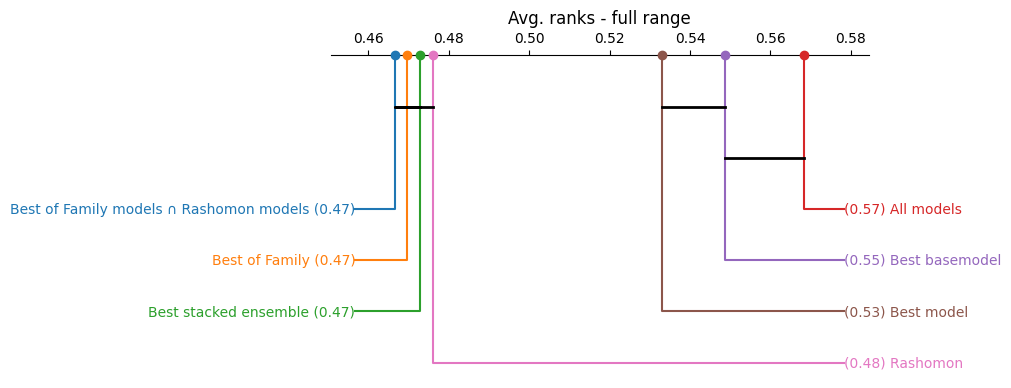

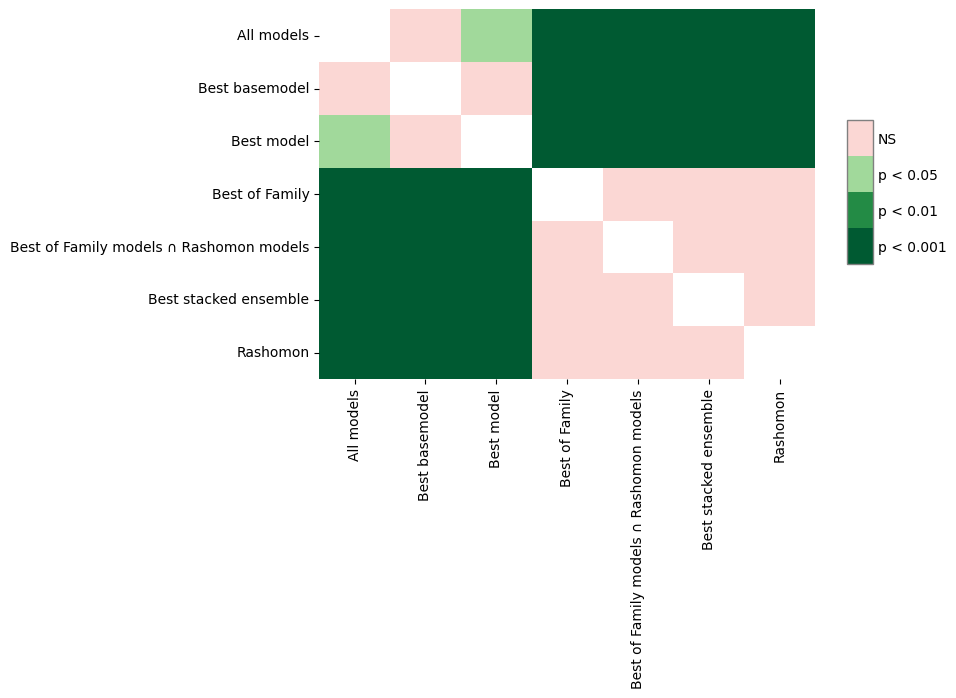


Avg. ranks - inner quartiles
model
All models                                 0.565109
Best basemodel                             0.590562
Best model                                 0.563525
Best of Family                             0.451321
Best of Family models ∩ Rashomon models    0.452713
Best stacked ensemble                      0.453287
Rashomon                                   0.444006
Name: value, dtype: float64


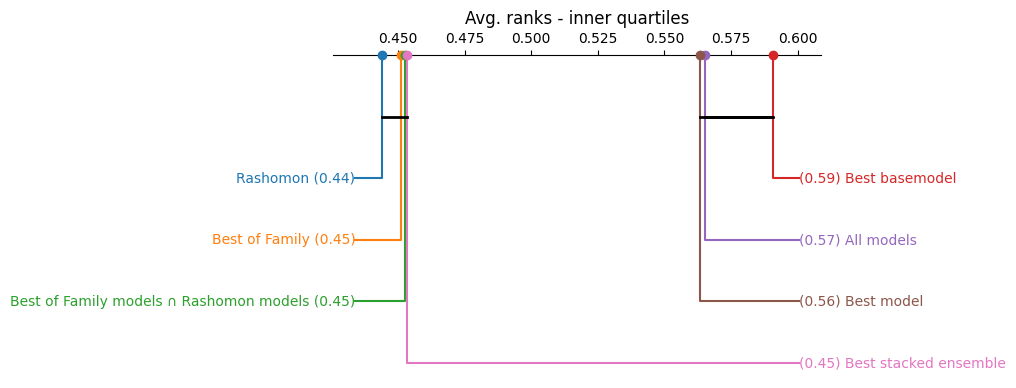

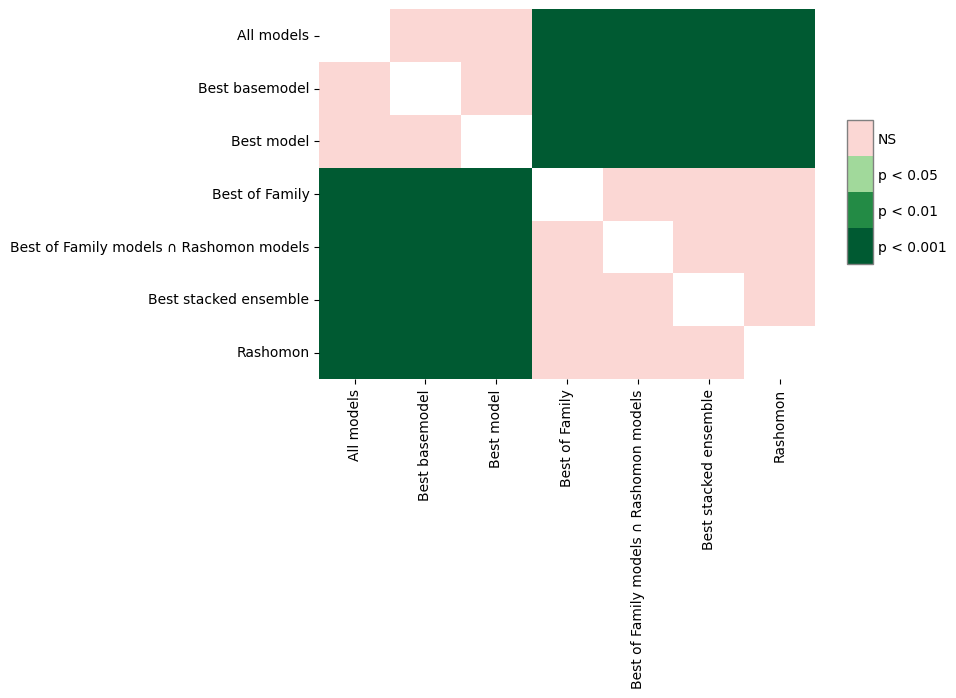


Avg. ranks - outer quartiles
model
All models                                 0.567382
Best basemodel                             0.547541
Best model                                 0.530097
Best of Family                             0.481658
Best of Family models ∩ Rashomon models    0.470401
Best stacked ensemble                      0.484458
Rashomon                                   0.490139
Name: value, dtype: float64


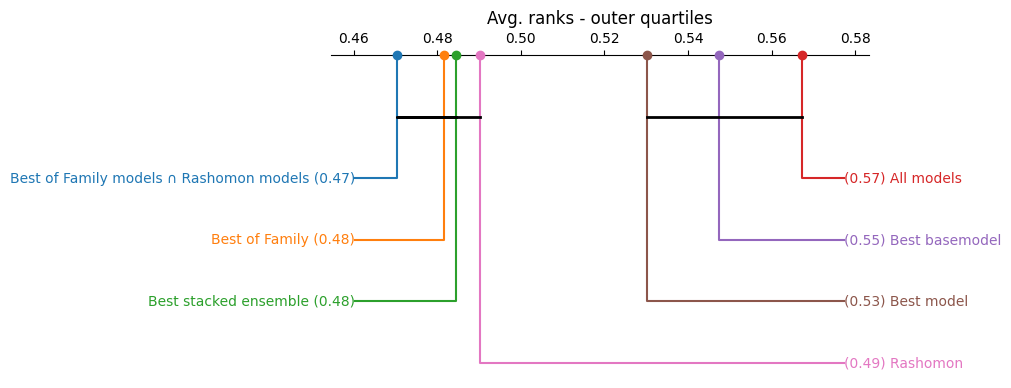

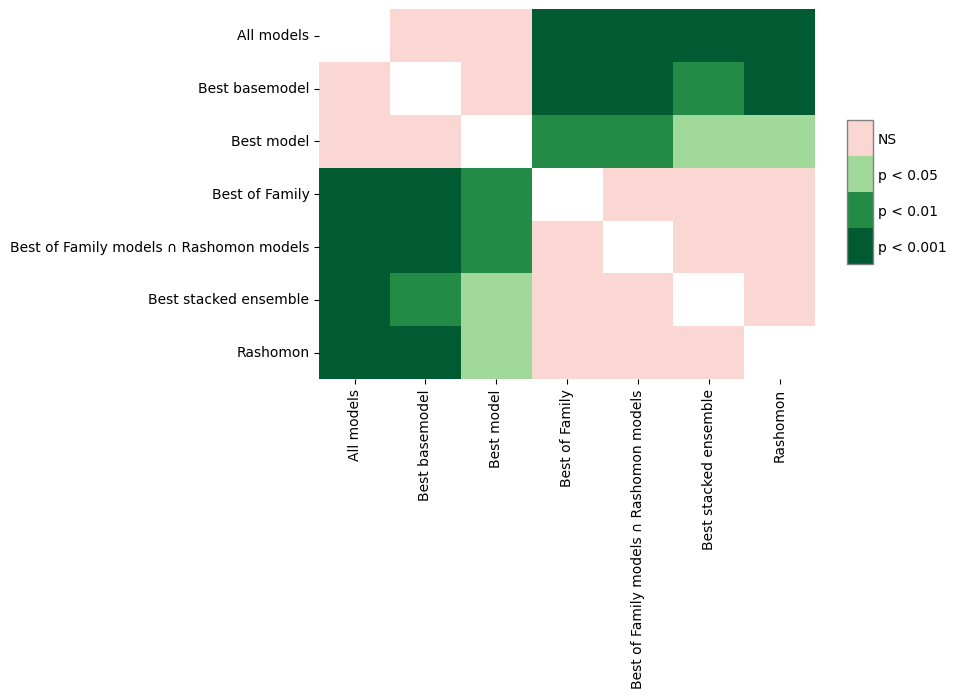


Avg. ranks - full range (noise_level == 1)
model
All models                                 0.606206
Best basemodel                             0.540237
Best model                                 0.533182
Best of Family                             0.483049
Best of Family models ∩ Rashomon models    0.447053
Best stacked ensemble                      0.494308
Rashomon                                   0.447133
Name: value, dtype: float64


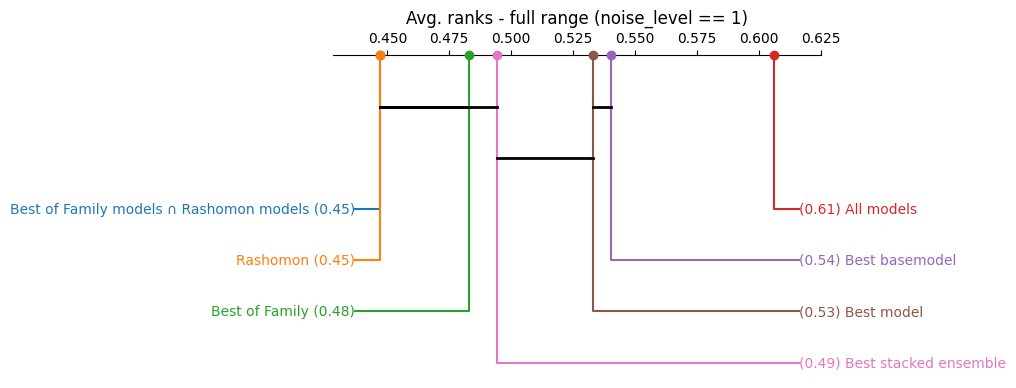

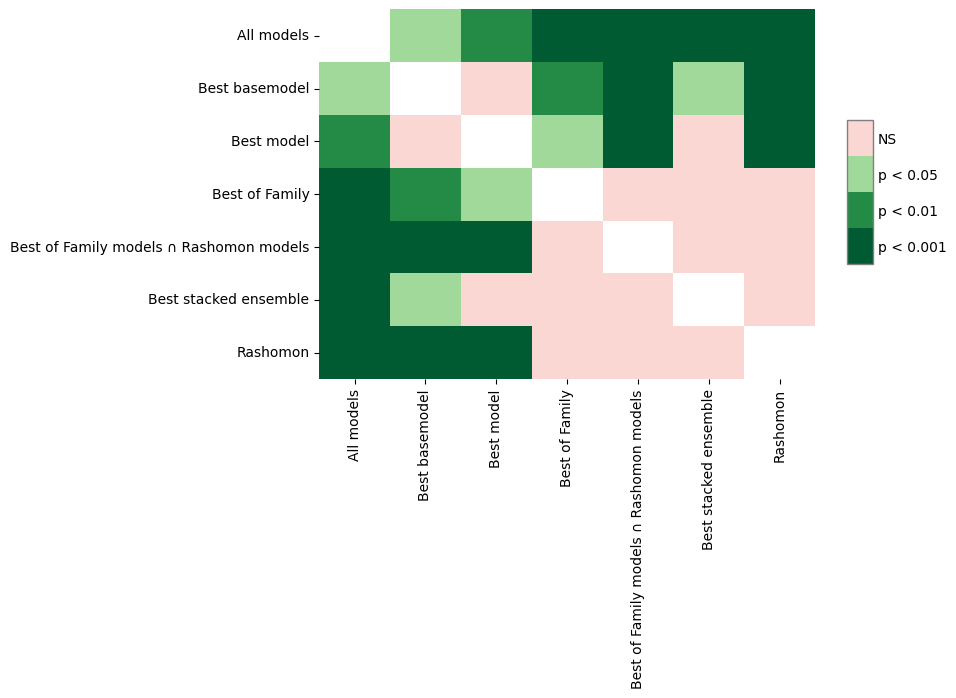


Avg. ranks - inner quartiles (noise_level == 1)
model
All models                                 0.606145
Best basemodel                             0.579056
Best model                                 0.568364
Best of Family                             0.462859
Best of Family models ∩ Rashomon models    0.449637
Best stacked ensemble                      0.493506
Rashomon                                   0.390983
Name: value, dtype: float64


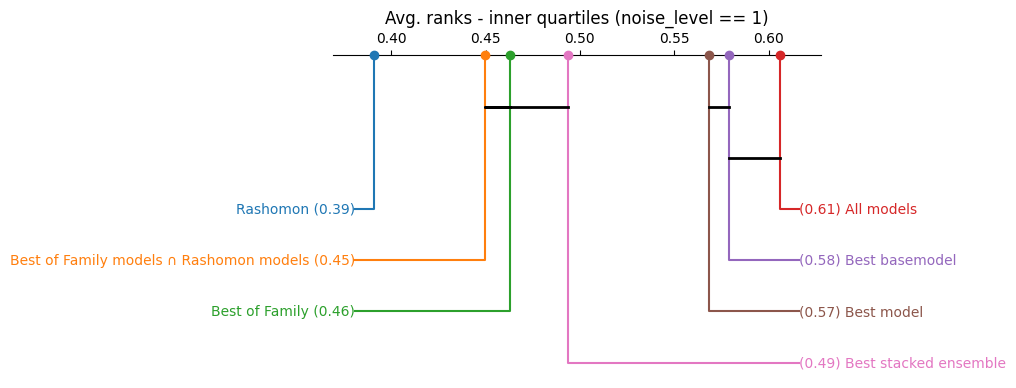

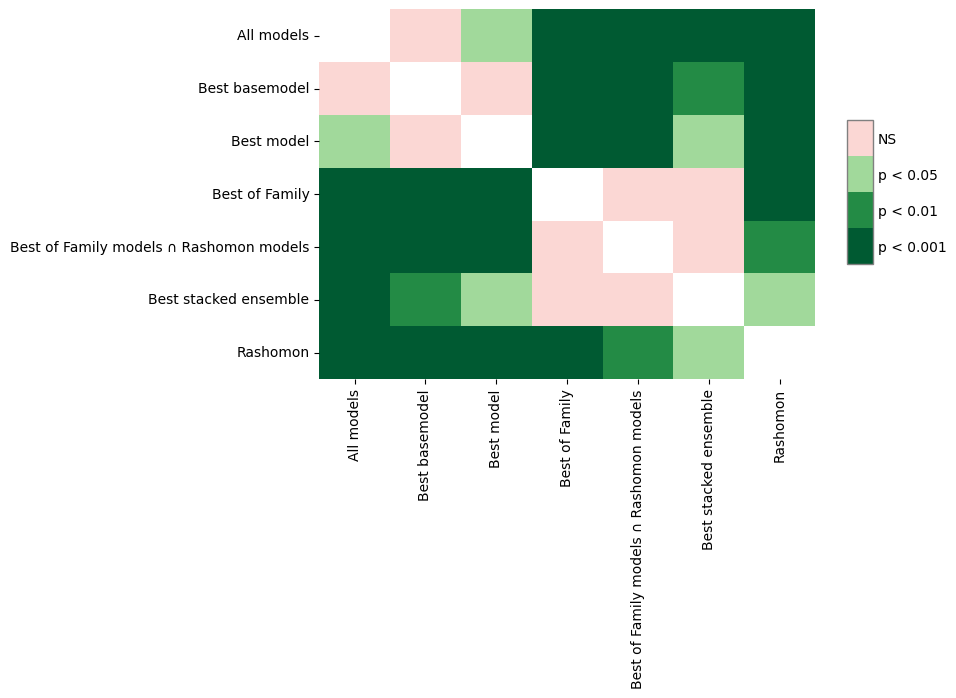


Avg. ranks - outer quartiles (noise_level == 1)
model
All models                                 0.602596
Best basemodel                             0.543885
Best model                                 0.528177
Best of Family                             0.486359
Best of Family models ∩ Rashomon models    0.448867
Best stacked ensemble                      0.484488
Rashomon                                   0.477003
Name: value, dtype: float64


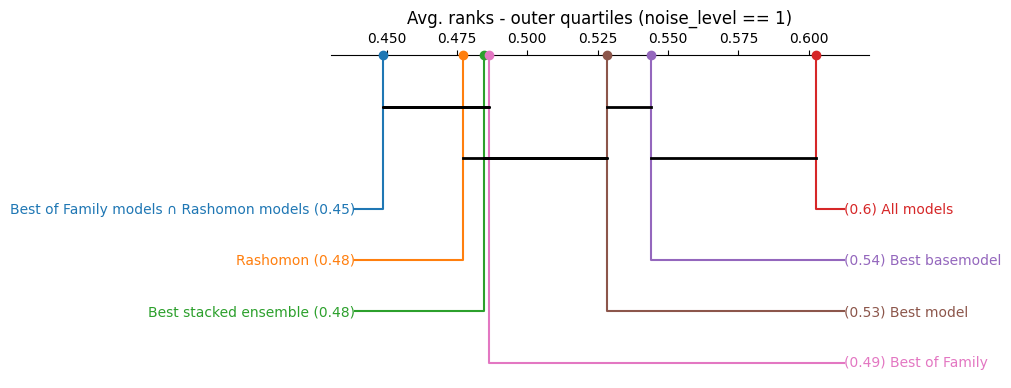

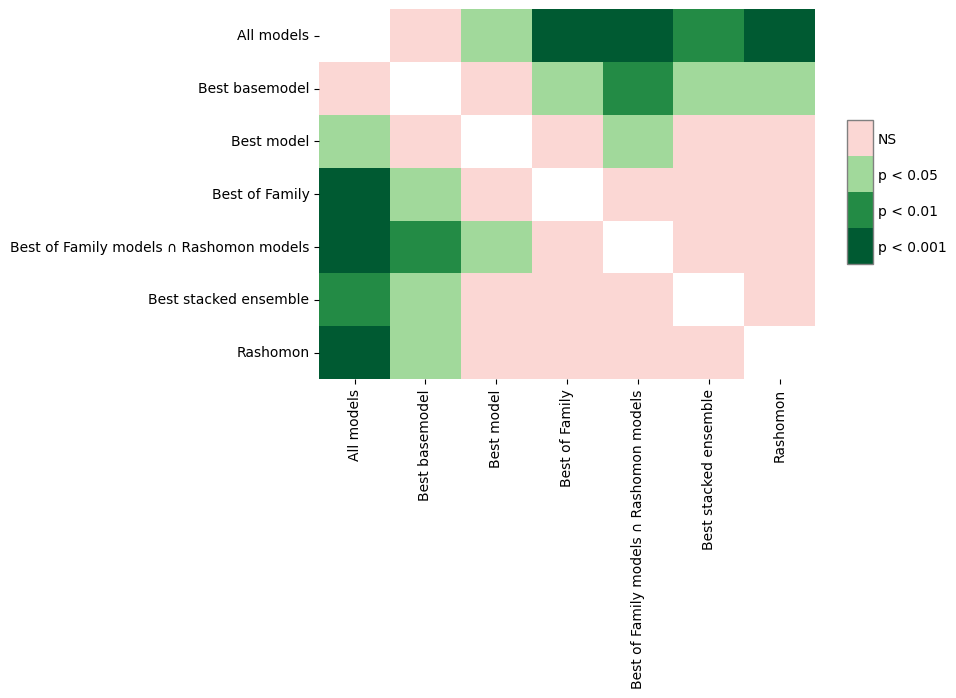


Avg. ranks - full range (noise_level == 4)
model
All models                                 0.545629
Best basemodel                             0.547298
Best model                                 0.526519
Best of Family                             0.480661
Best of Family models ∩ Rashomon models    0.503883
Best stacked ensemble                      0.457129
Rashomon                                   0.463177
Name: value, dtype: float64


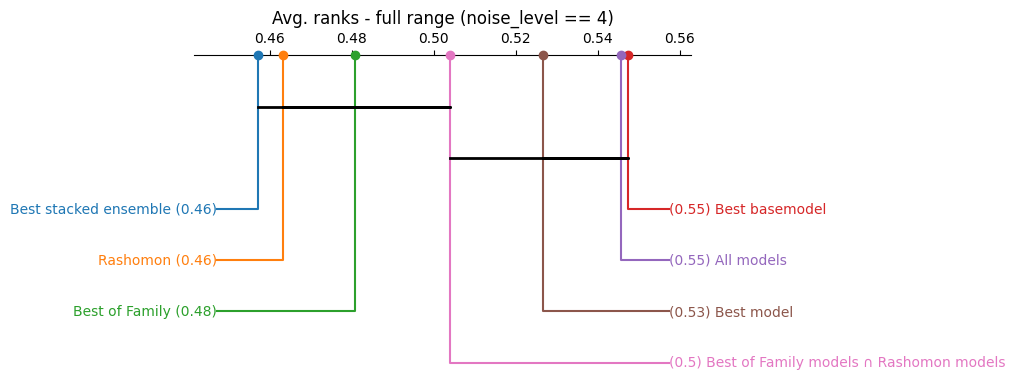

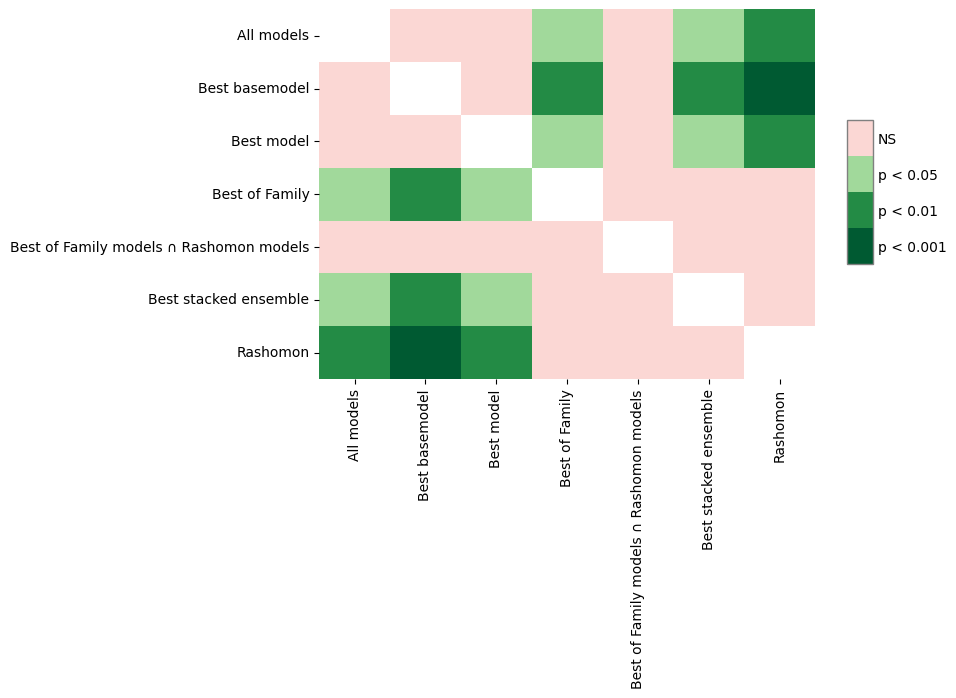


Avg. ranks - inner quartiles (noise_level == 4)
model
All models                                 0.539254
Best basemodel                             0.579062
Best model                                 0.544395
Best of Family                             0.470342
Best of Family models ∩ Rashomon models    0.504072
Best stacked ensemble                      0.423891
Rashomon                                   0.439043
Name: value, dtype: float64


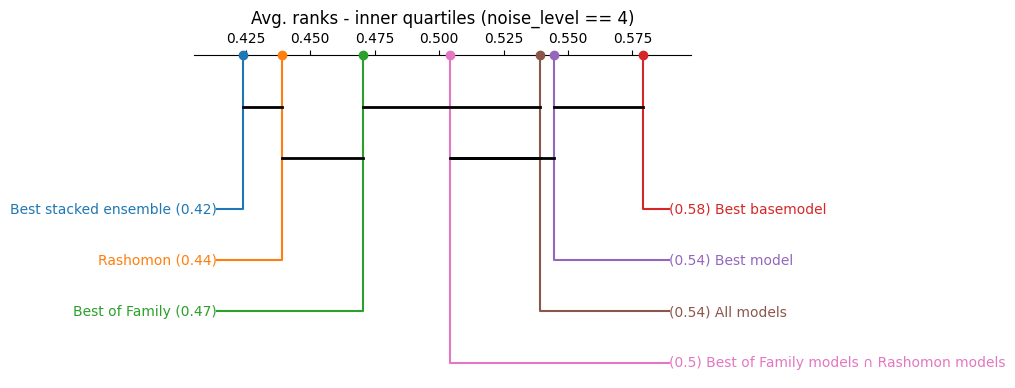

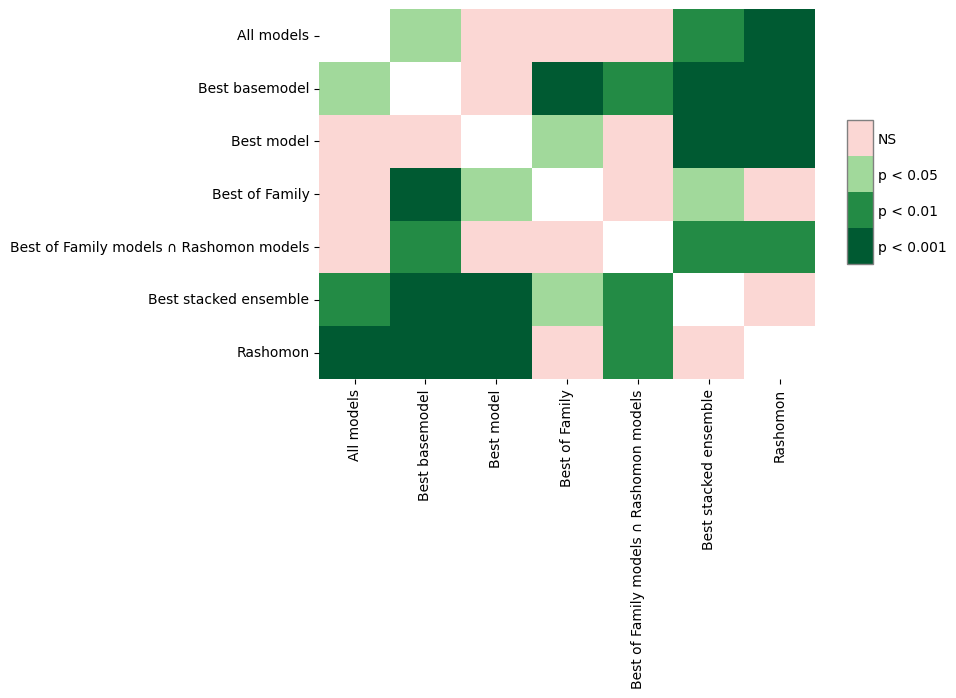


Avg. ranks - outer quartiles (noise_level == 4)
model
All models                                 0.548721
Best basemodel                             0.544643
Best model                                 0.527530
Best of Family                             0.487027
Best of Family models ∩ Rashomon models    0.502046
Best stacked ensemble                      0.481990
Rashomon                                   0.478243
Name: value, dtype: float64


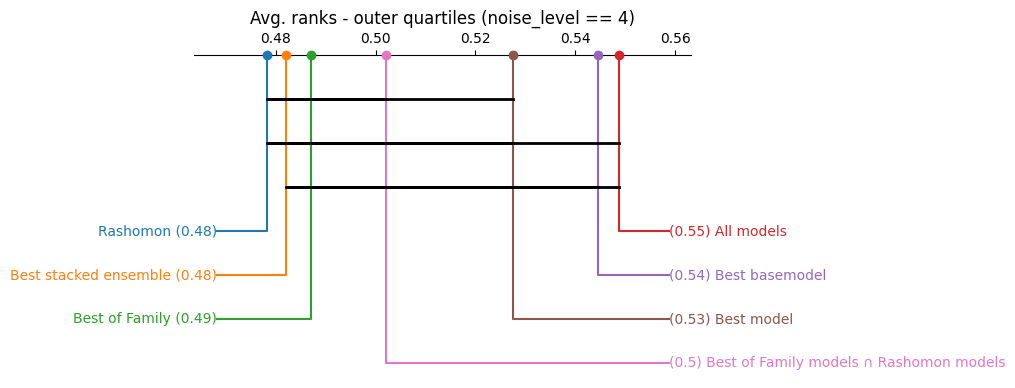

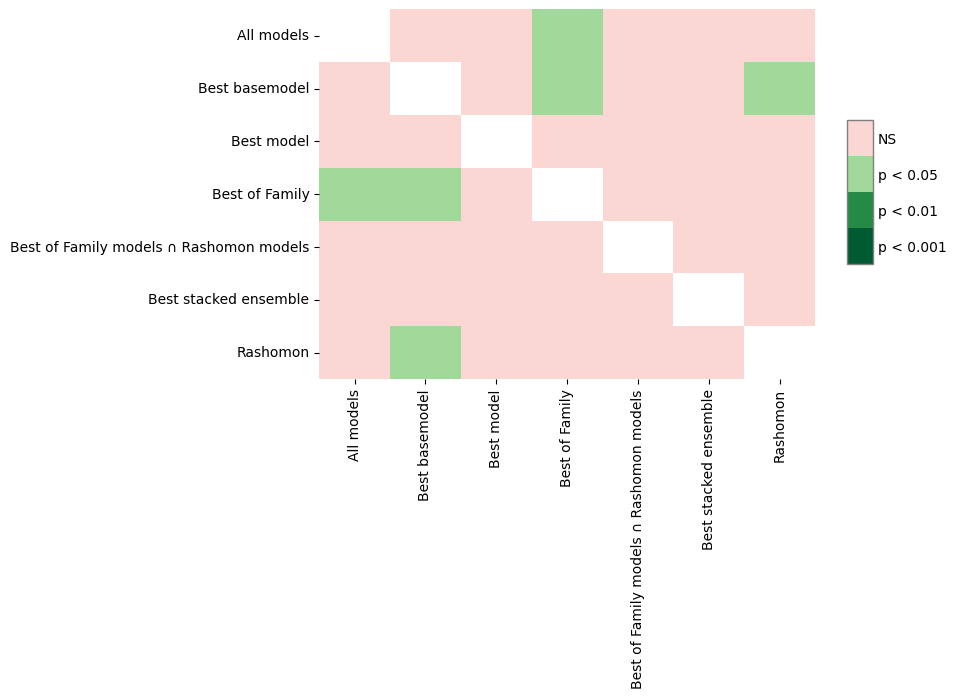


Avg. ranks - full range (noise_level == 9)
model
All models                                 0.553155
Best basemodel                             0.558740
Best model                                 0.539450
Best of Family                             0.444748
Best of Family models ∩ Rashomon models    0.449236
Best stacked ensemble                      0.469871
Rashomon                                   0.517759
Name: value, dtype: float64


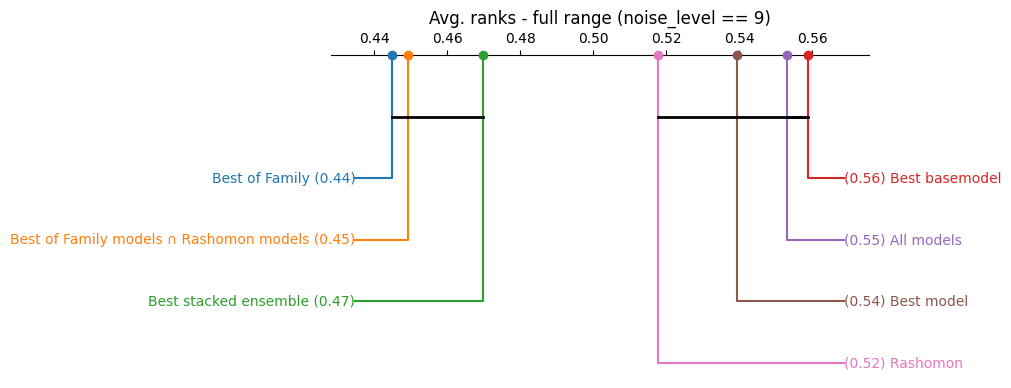

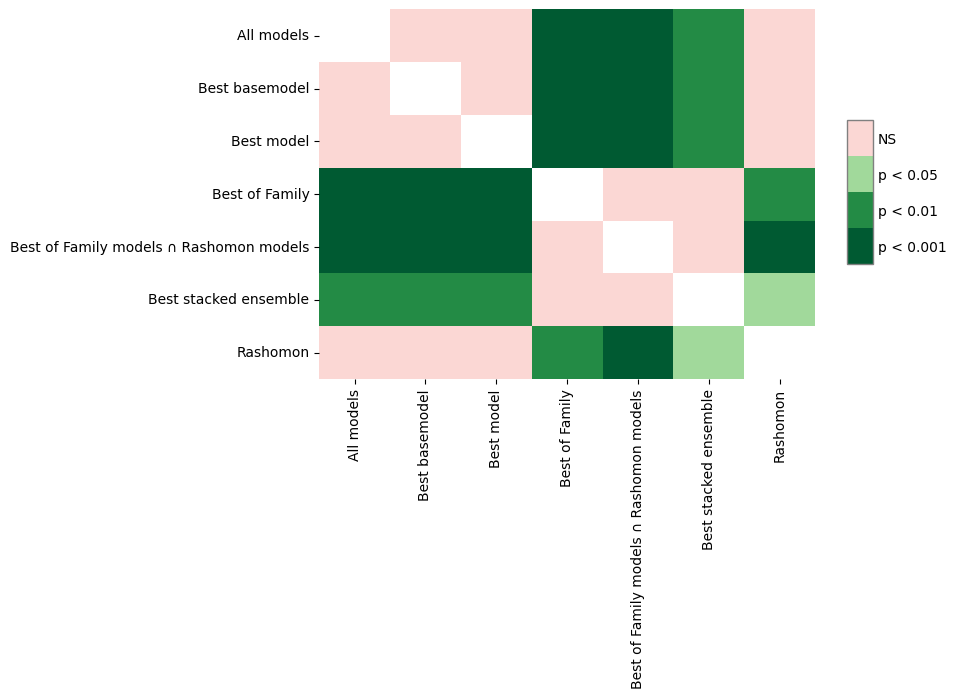


Avg. ranks - inner quartiles (noise_level == 9)
model
All models                                 0.549928
Best basemodel                             0.613567
Best model                                 0.577816
Best of Family                             0.420760
Best of Family models ∩ Rashomon models    0.404428
Best stacked ensemble                      0.448266
Rashomon                                   0.501990
Name: value, dtype: float64


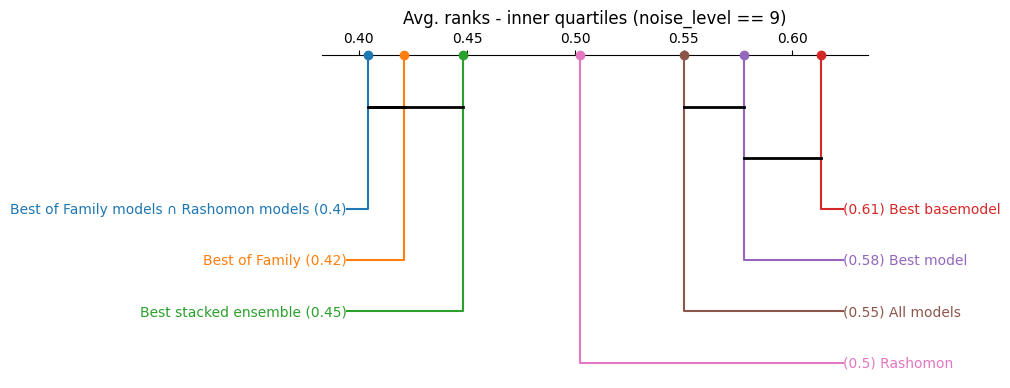

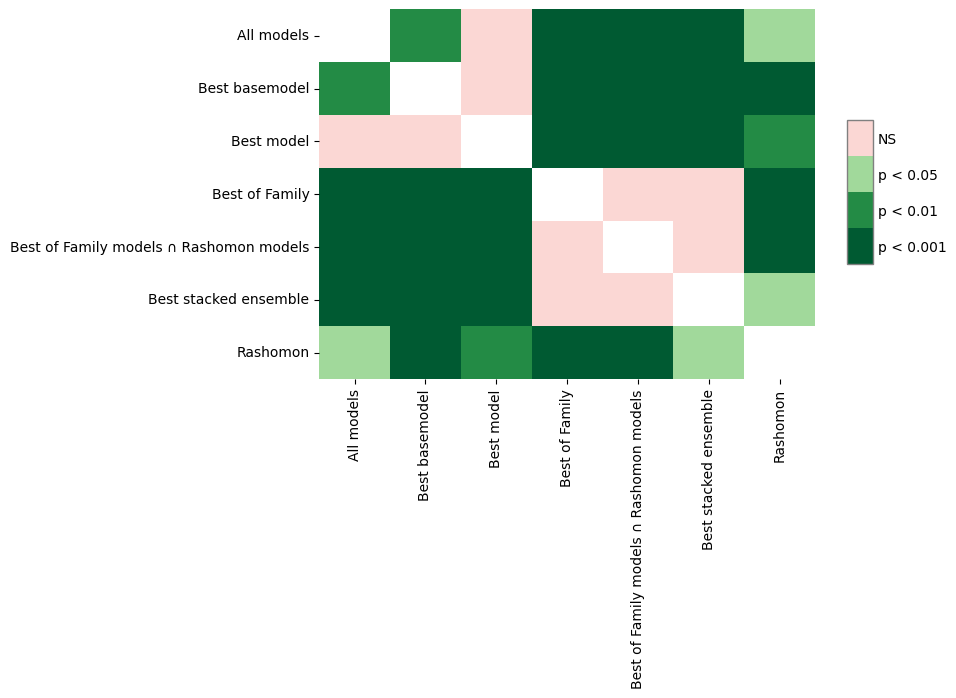


Avg. ranks - outer quartiles (noise_level == 9)
model
All models                                 0.550829
Best basemodel                             0.554095
Best model                                 0.534584
Best of Family                             0.471588
Best of Family models ∩ Rashomon models    0.460290
Best stacked ensemble                      0.487103
Rashomon                                   0.515170
Name: value, dtype: float64


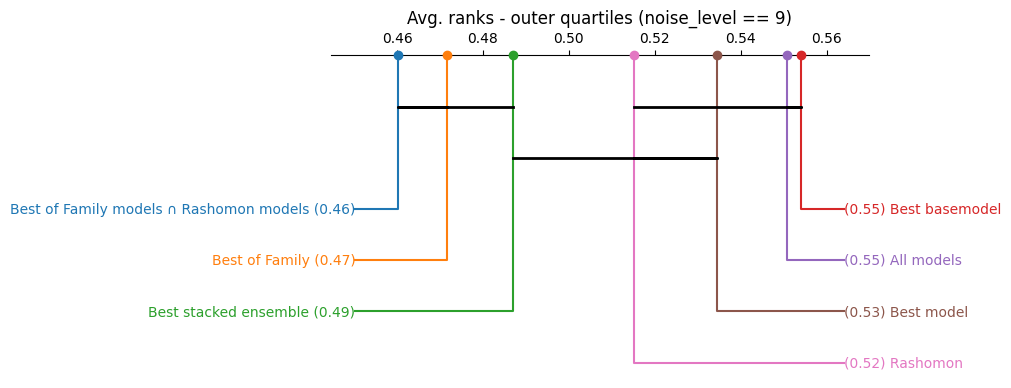

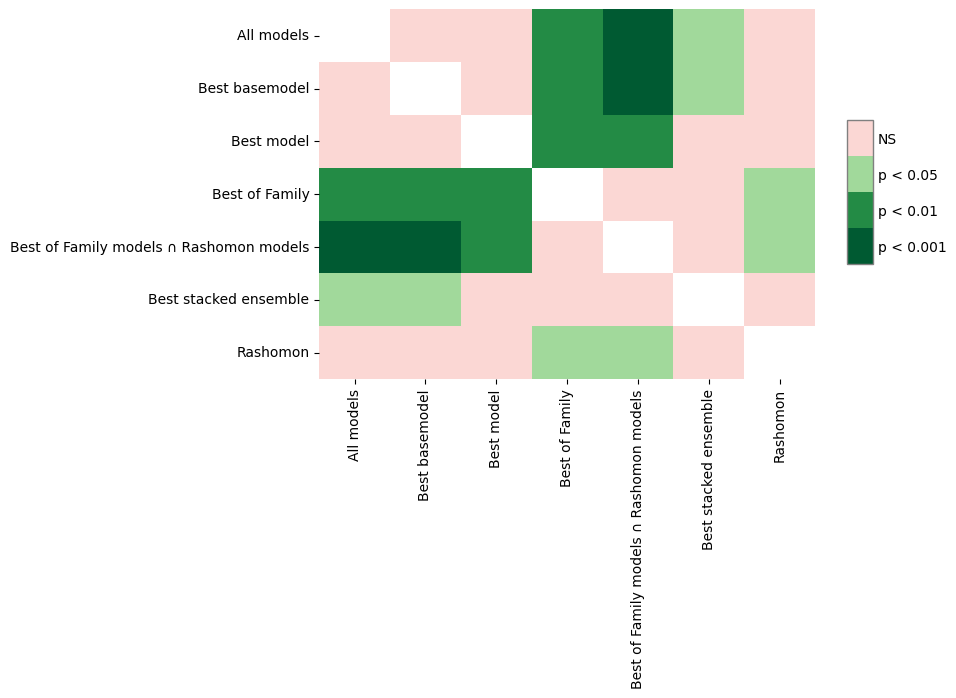

In [8]:
def stats(subset, title, save_to=None):
    header(title, "=")
    avg_rank = subset.groupby('file').value.rank(pct=True).groupby(subset.model).mean()
    print(avg_rank)
    test_results = sp.posthoc_conover(
        subset,
        group_col='model',
        val_col='value',
    )
    plt.figure(figsize=(10,4))
    sp.critical_difference_diagram(avg_rank, test_results)
    plt.title(title)
    plt.tight_layout()
    if save_to:
        plt.savefig(save_to)
    plt.show()
    sp.sign_plot(test_results)
    plt.show()


##################################

subset = melted[(melted.metric == "mean_distance") & (melted.part == "full")].dropna()
stats(subset, "Avg. ranks - full range", "avg_ranks_full_range.png")

subset = melted[(melted.metric == "mean_distance") & (melted.part == "inner-q0.25")].dropna()
stats(subset, "Avg. ranks - inner quartiles", "avg_ranks_inner_half.png")

subset = melted[(melted.metric == "mean_distance") & (melted.part == "outer-q0.25")].dropna()
stats(subset, "Avg. ranks - outer quartiles", "avg_ranks_outer_half.png")

for noise in ["1", "4", "9"]:
    subset = melted[(melted.metric == "mean_distance") & (melted.part == "full") & (melted.noise_level == noise)].dropna()
    stats(subset, f"Avg. ranks - full range (noise_level == {noise})", f"avg_ranks_full_range_noise_{noise}.png")
    
    subset = melted[(melted.metric == "mean_distance") & (melted.part == f"inner-q0.25") & (melted.noise_level == noise)].dropna()
    stats(subset, f"Avg. ranks - inner quartiles (noise_level == {noise})", f"avg_ranks_inner_half_noise_{noise}.png")
    
    subset = melted[(melted.metric == "mean_distance") & (melted.part == "outer-q0.25") & (melted.noise_level == noise)].dropna()
    stats(subset, f"Avg. ranks - outer quartiles (noise_level == {noise})", f"avg_ranks_outer_half_noise_{noise}.png")

#subset = melted[(melted.metric == "mean_distance") & (melted.part == "inner-q0.1")].dropna()
#subset = melted[(melted.metric == "mean_distance") & (melted.part == "outer-q0.1")].dropna()

#subset = melted[(melted.metric == "root_mean_square_distance") & (melted.part == "full")].dropna()
#subset = melted[(melted.metric == "root_mean_square_distance") & (melted.part == "inner-q0.25")].dropna()
#subset = melted[(melted.metric == "root_mean_square_distance") & (melted.part == "outer-q0.25")].dropna()

